[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/crefossus/VocEd/blob/main/Projects/project_2_outline.ipynb)

# Project 2 — Bayesian Optimization of Threshold-Based Segmentation

**Topic:** Automated segmentation of urothelial cell images using grayscale thresholding and Bayesian optimisation.

**Prerequisite labs:** Lab 01, Lab 02, Lab 03, Lab 03v2

This project is structured in three stages of increasing open-endedness:

| Stage | Character | Based on |
|---|---|---|
| **Stage 1** | Guided — concrete tasks, specific deliverables | Labs 01 & 02 |
| **Stage 2** | Semi-open — choose your investigations, justify your choices | Lab 03 & 03v2 |
| **Stage 3** | Open-ended — design your best system, write a full report | All labs + your own ideas |

Throughout all three stages the core problem stays the same: segment urothelial cell images into background / cytoplasm / nucleus using threshold-based methods, and measure quality with **Dice score** and **N/C ratio R²**.

---

## Submission

Submit one Colab notebook per stage (or one combined notebook with clearly labelled sections). Each stage specifies exactly what to include. Written answers should appear in markdown cells directly below the relevant code.

## Setup

In [3]:
#%pip install scikit-optimize scikit-image --quiet

#%git clone https://github.com/Crefossus/VocEd.git
#%cd VocEd

200 images found
9 images with no nuclei
Indexes of images with no nuclei: [ 34  36  56 118 121 122 133 134 156]


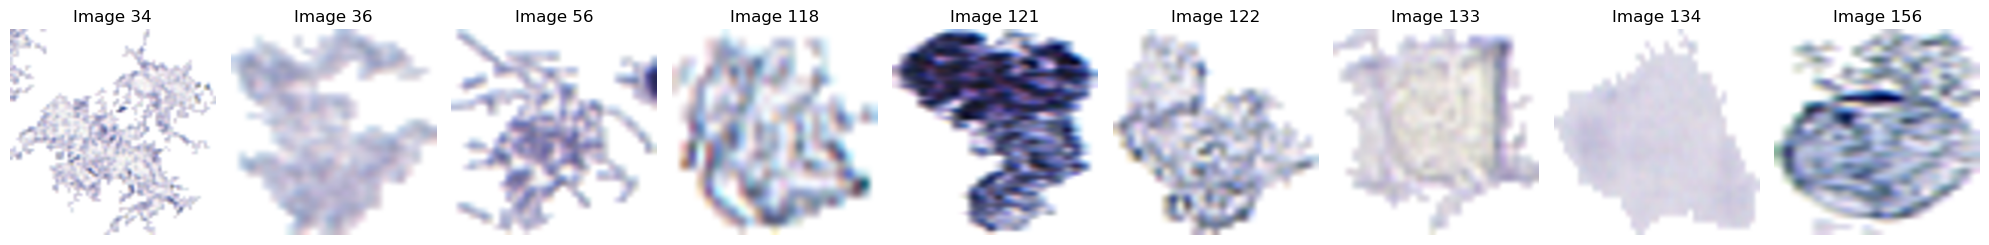

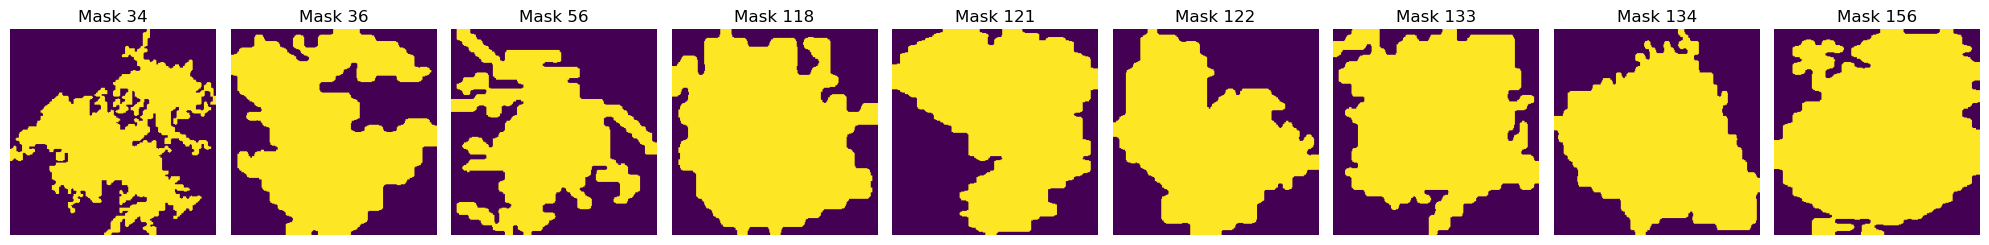

191 images with nuclei
191 images  |  train: 152  test: 39


In [7]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split

# ── Load data ──────────────────────────────────────────────────────────────
imagePath = "../imagedata/images/"
maskPath = "../imagedata/masks/"

imageCount = len(glob.glob(imagePath + '*.npy'))
print(f'{imageCount} images found')
images = np.stack([np.load(imagePath + f'{i}.npy') for i in range(imageCount)])
masks = np.stack([np.load(maskPath + f'{i}.npy') for i in range(imageCount)])

noNuclei = (masks == 2).sum(axis=(1, 2)) == 0
print(f'{noNuclei.sum()} images with no nuclei')

#output all indexes of images with no nuclei
print('Indexes of images with no nuclei:', np.where(noNuclei)[0])


# TODO: combine both loops, also basing image index off of masks which could get desynced from images

#use imgshow to show all images without nuclei 
fig, axes = plt.subplots(1, noNuclei.sum(), figsize=(20, 4))
for i in range(noNuclei.sum()):
    imageIndex = np.where(noNuclei)[0][i]
    axes[i].imshow(images[imageIndex].transpose(1, 2, 0))
    axes[i].set_title(f'Image {imageIndex}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# use imgshow to show all masks without nuclei and display their masks
fig, axes = plt.subplots(1, noNuclei.sum(), figsize=(20, 4))
for i in range(noNuclei.sum()):
    maskIndex = np.where(noNuclei)[0][i]
    axes[i].imshow(masks[maskIndex])
    axes[i].set_title(f'Mask {maskIndex}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# ── Drop images with no nucleus  ────────────────────────────────────────────
hasNucleus = (masks == 2).sum(axis=(1, 2)) > 0
images, masks = images[hasNucleus], masks[hasNucleus]
N = len(images)
print(f'{N} images with nuclei')


# ── Stratified train/test split (stratify by N/C ratio) ────────────────────
nuc_px   = (masks == 2).sum(axis=(1, 2))
cyt_px   = (masks == 1).sum(axis=(1, 2))
nc_ratio = nuc_px / np.maximum(cyt_px, 1)
quartile = np.digitize(nc_ratio, np.percentile(nc_ratio, [25, 50, 75]))

train_idx, test_idx = train_test_split(
    np.arange(N), test_size=0.2, stratify=quartile, random_state=42
)

mask_cmap = ListedColormap(['black', 'steelblue', 'crimson'])
print(f'{N} images  |  train: {len(train_idx)}  test: {len(test_idx)}')

### Shared helper functions

These functions are used throughout all three stages. They are identical to the ones from Labs 01–03.

In [8]:
def to_gray(img):
    """(3, H, W) float32 → (H, W) float32 grayscale."""
    return 0.299 * img[0] + 0.587 * img[1] + 0.114 * img[2]

def segment(img, t_nucleus, t_background):
    """Two-threshold grayscale segmenter. Returns (H, W) int64 mask."""
    gray = to_gray(img)
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                 = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]     = 1
    return pred

def dice_score(pred, target, cls):
    """Dice coefficient for a single class."""
    p = (pred == cls)
    t = (target == cls)
    denom = p.sum() + t.sum()
    return 1.0 if denom == 0 else 2 * (p & t).sum() / denom

def mean_dice(indices, t_nuc, t_bg):
    """Mean Dice (avg of cytoplasm + nucleus) over a list of image indices."""
    scores = []
    for i in indices:
        pred = segment(images[i], t_nuc, t_bg)
        scores.append((dice_score(pred, masks[i], 1) + dice_score(pred, masks[i], 2)) / 2)
    return np.mean(scores)

def nc_ratio(mask):
    """N/C ratio: nucleus pixels / cytoplasm pixels. NaN if no cytoplasm."""
    nuc = (mask == 2).sum()
    cyt = (mask == 1).sum()
    if cyt == 0:
        print('Warning: cytoplasm pixel count is zero, returning NaN for N/C ratio')
    return nuc / cyt if cyt > 0 else np.nan

def r2_identity(yp, gt):
    """R² vs y = x (identity line). 1 = perfect; falls with any deviation."""
    ok  = np.isfinite(yp) & np.isfinite(gt)
    p, g = yp[ok], gt[ok]
    return 1 - np.sum((p - g) ** 2) / np.sum((g - g.mean()) ** 2)

print('Helpers loaded.')

Helpers loaded.


---

# Stage 1 — Guided Exploration

This stage has four concrete tasks. Each one has a specified output (a plot, a table, or a short written answer). Complete them in order — later tasks build on earlier ones.

**Time estimate:** 2–3 hours.

## Task 1.1 — The N/C Ratio Distribution

Before building any model it is important to understand the *target variable* — the N/C ratio that clinicians use as a diagnostic feature.

**Your tasks:**

1. Compute the ground-truth N/C ratio for every image in the full dataset (use the    `nc_ratio` helper above on each mask `y[i]`). Skip images where the ratio is NaN    (no cytoplasm).
2. Plot a histogram of the N/C ratio distribution (20–30 bins, labelled axes).
3. Print the mean, median, standard deviation, and the 10th / 90th percentiles.

**Written answer (in a markdown cell below your code):**

- What does a high N/C ratio indicate clinically?
- Looking at the histogram, would you describe the distribution as symmetric?   What does the shape tell you about the mix of cell types in the dataset?
- The train/test split is *stratified* by N/C ratio quartile. In one sentence, explain   why this is preferable to a random split for this task.

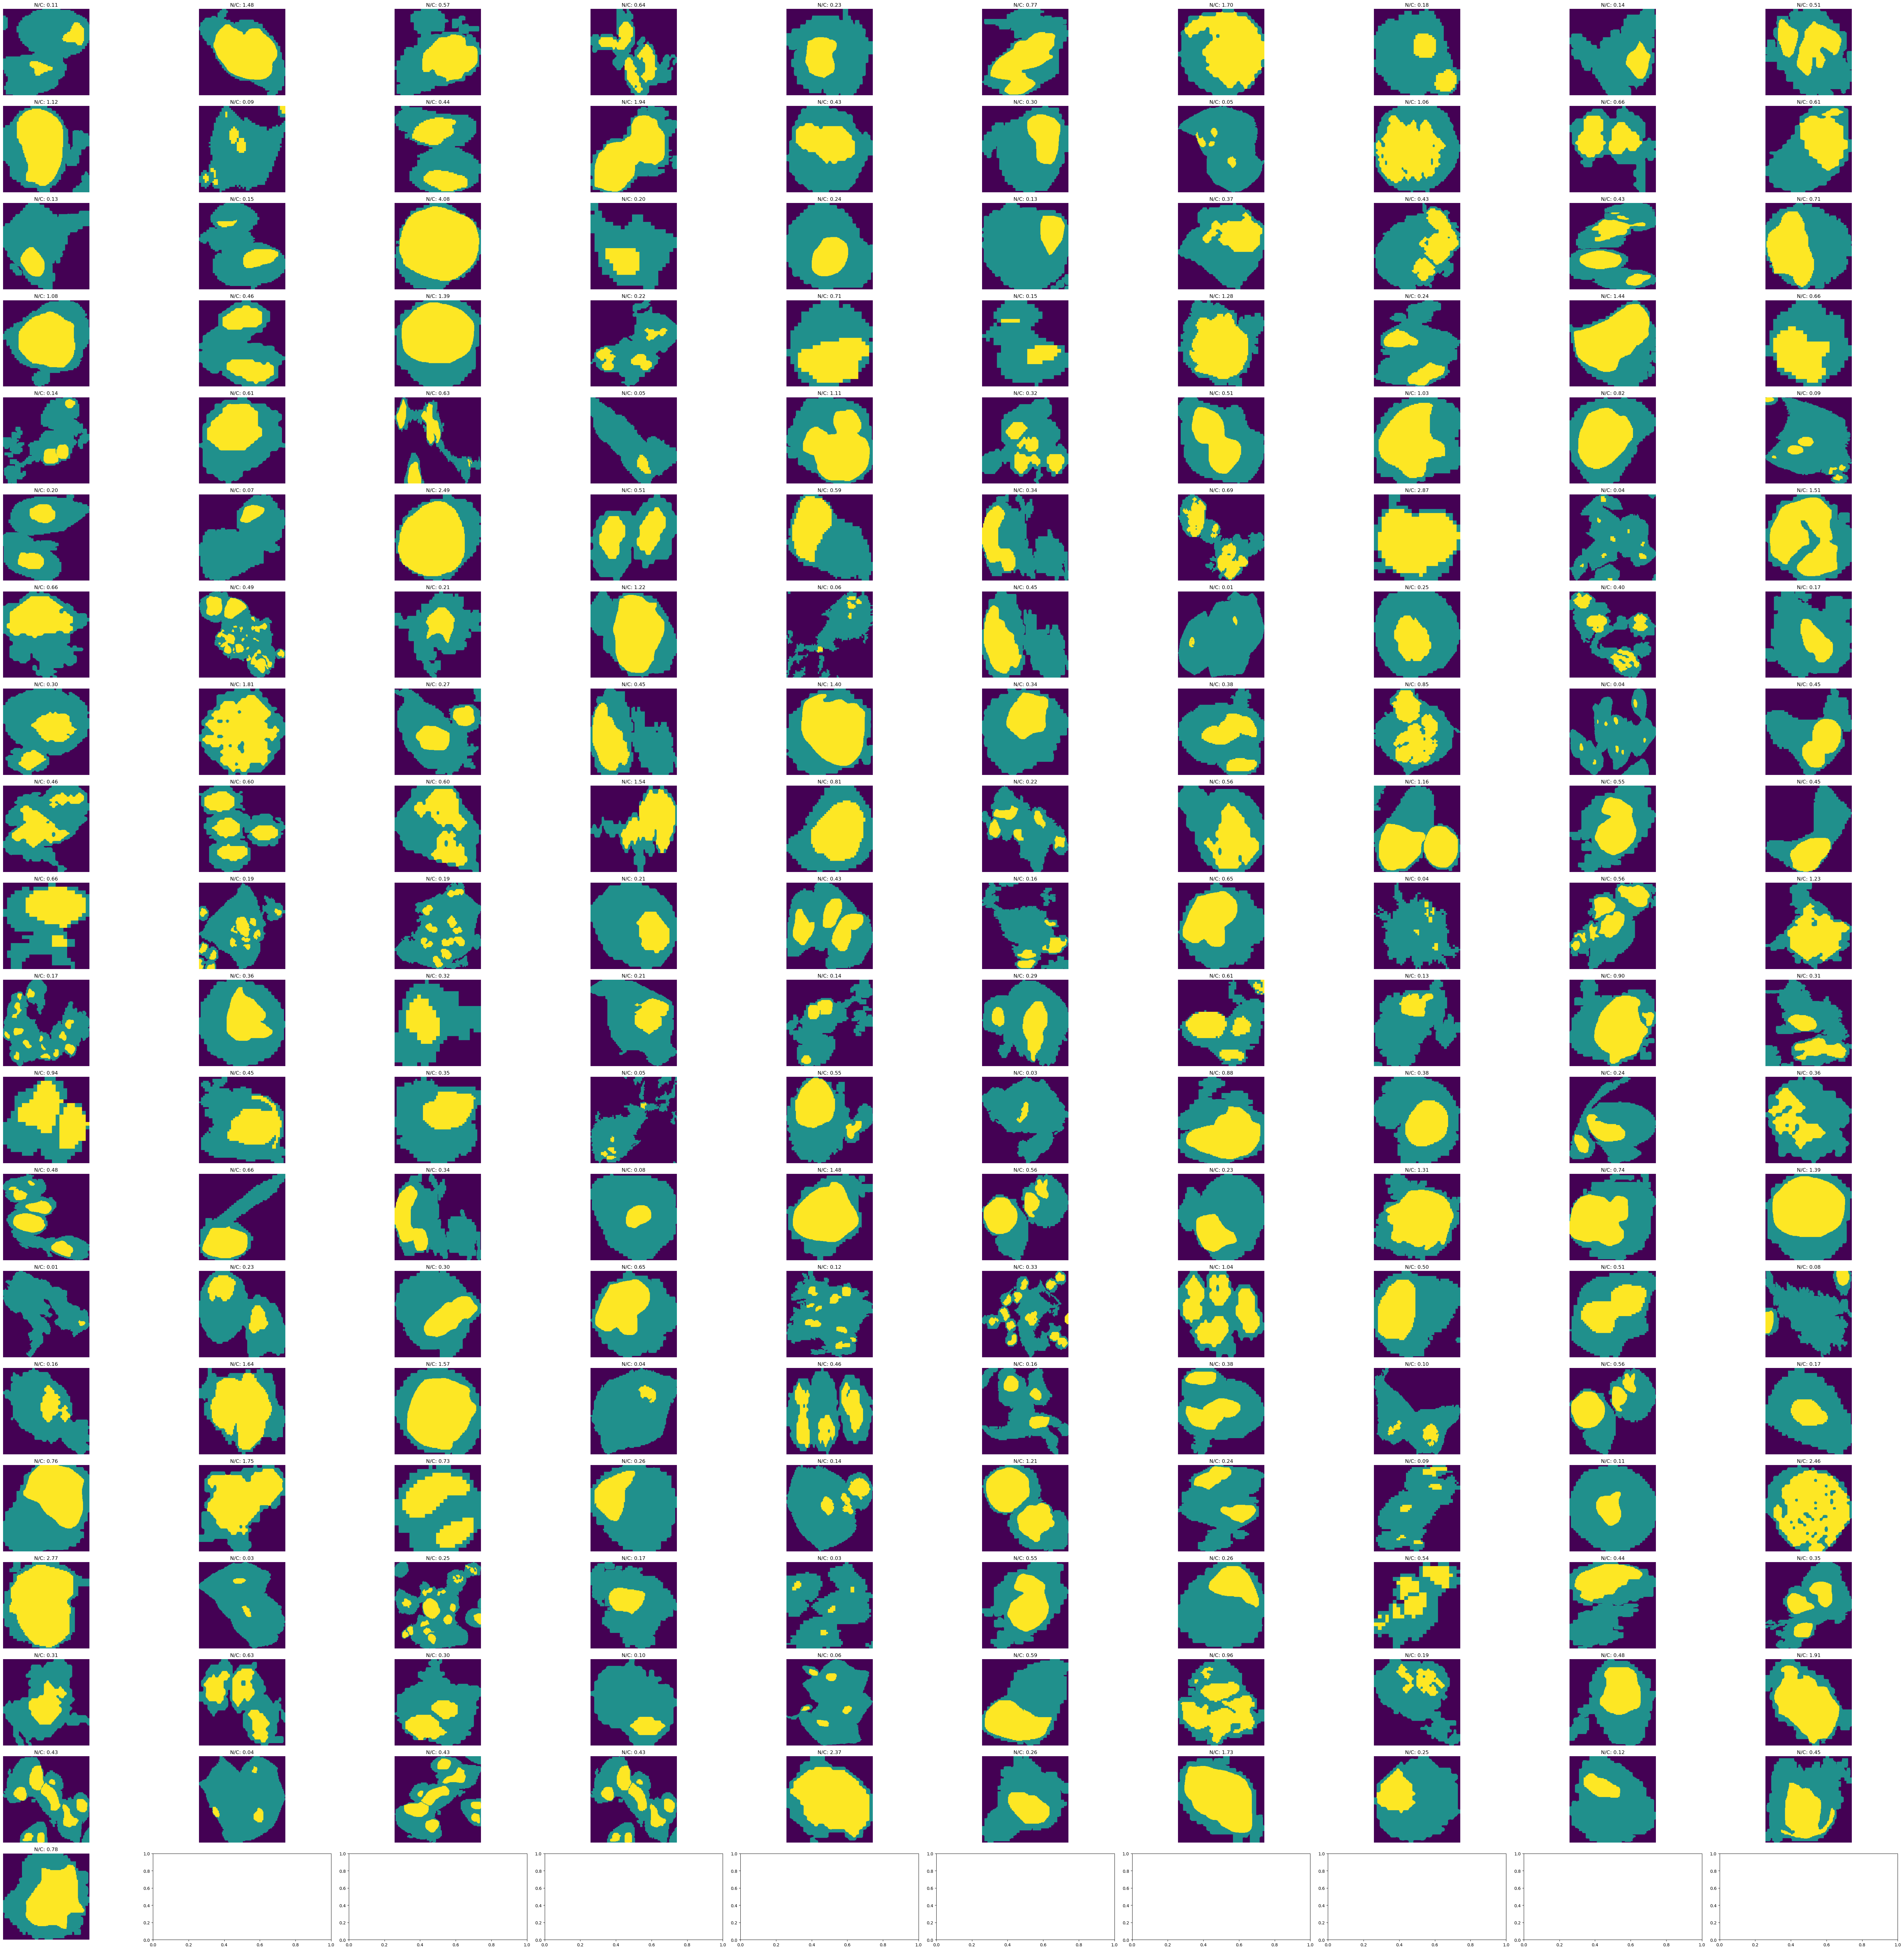

191 valid N/C ratios computed


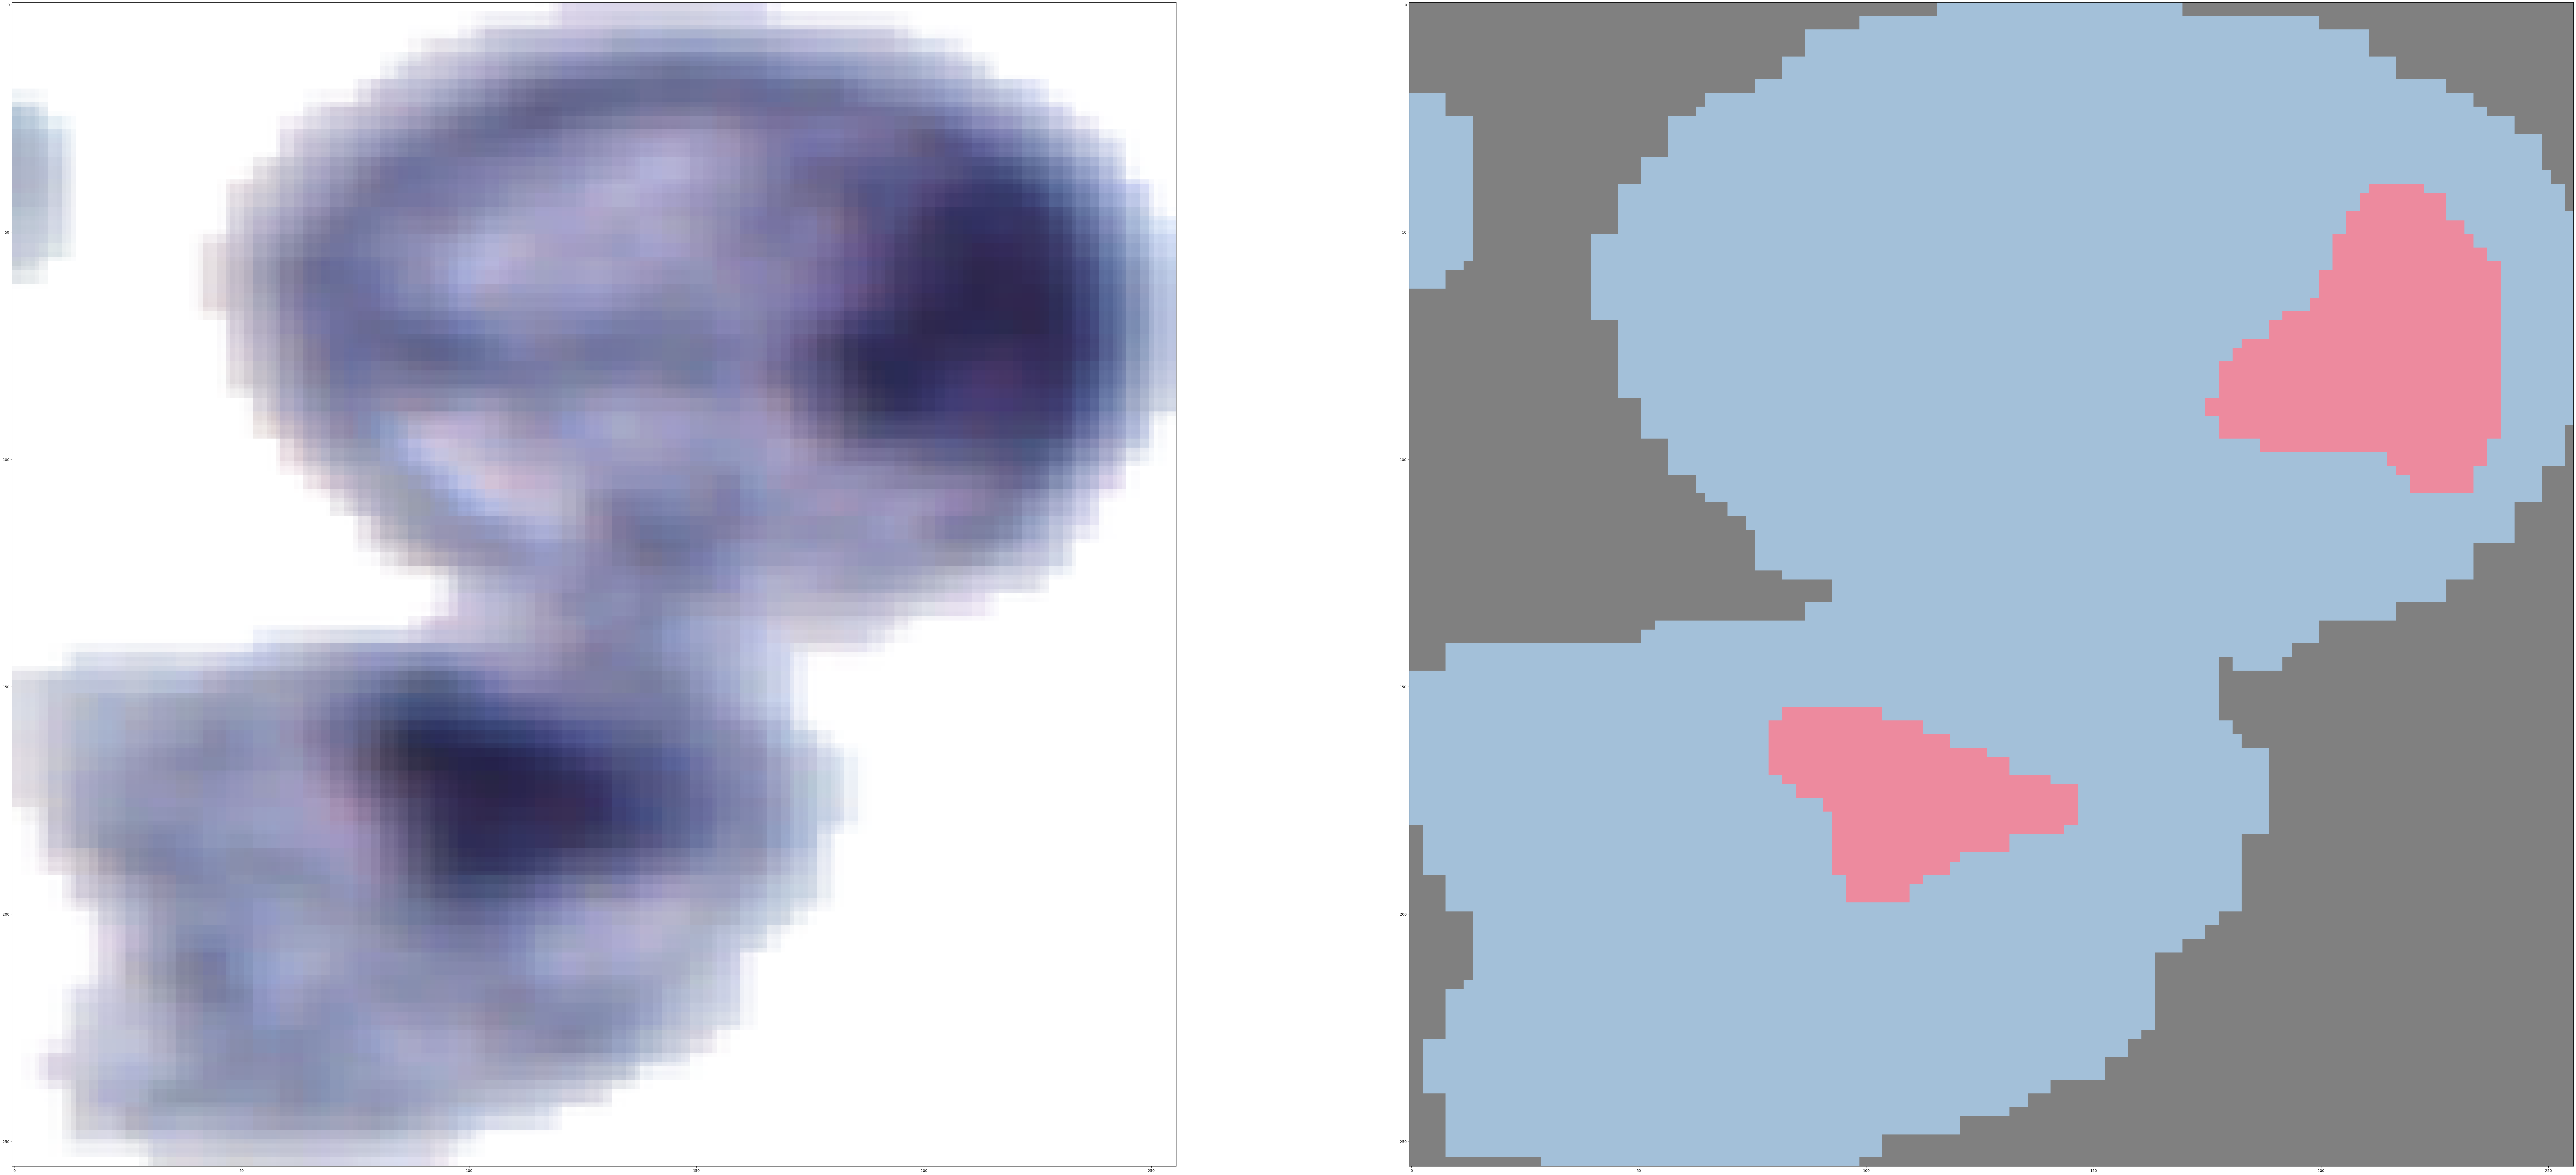

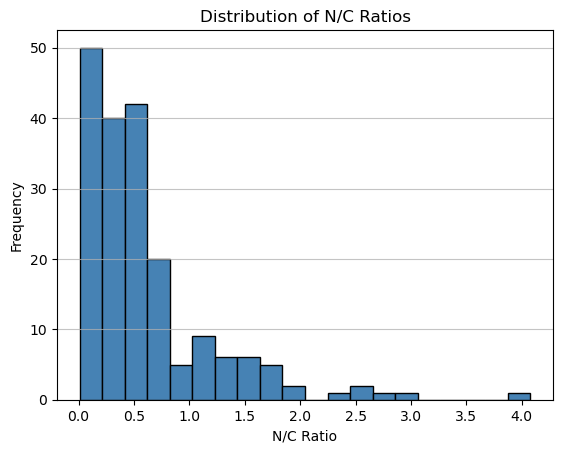

Mean N/C Ratio: 0.59
Median N/C Ratio: 0.43
Standard Deviation: 0.61


In [ ]:
# ── Task 1.1 ─────────────────────────────────────────────────────────────────
#compute ground-truth N/C ratios for all images
#error checking for zero cytoplasm pixels is handled in nc_ratio function
#all our images have cytoplasm in the mask, so this is weird
nc_true_all = np.array([nc_ratio(masks[i]) for i in range(N)])
valid        = np.isfinite(nc_true_all)
ncRatios = nc_true_all[valid]

#show all images next to their mask to explore the data
fig, axes = plt.subplots(20, 10, figsize=(64, 64))
for i in range(N):
    ax = axes[i // 10, i % 10]
    ax.imshow(masks[i])
    ax.set_title(f'N/C: {ncRatios[i]:.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'{len(ncRatios)} valid N/C ratios computed')

fig, axes = plt.subplots(1, 2, figsize=(128, 128))
axes[0].imshow(images[0].transpose(1, 2, 0))
axes[1].imshow(masks[0], alpha=0.5, cmap=mask_cmap)
plt.show()

                   
#plot histogram
plt.hist(ncRatios, bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of N/C Ratios')
plt.xlabel('N/C Ratio')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


#print summary statistics
print(f'Mean N/C Ratio: {ncRatios.mean():.2f}')
print(f'Median N/C Ratio: {np.median(ncRatios):.2f}')
print(f'Standard Deviation: {ncRatios.std():.2f}')


## Task 1.2 — Threshold Sensitivity Analysis

Lab 01 hand-picked `t_nucleus = 0.45` and `t_background = 0.85`. How sensitive is the result to small changes in each threshold?

**Your tasks:**

1. Vary `t_nucleus` from 0.25 to 0.55 in steps of 0.05, holding `t_background = 0.85`    fixed. For each value, compute `mean_dice(train_idx, t_nuc, 0.85)`. Plot Dice vs `t_nucleus`.
2. Vary `t_background` from 0.65 to 0.99 in steps of 0.05, holding `t_nucleus = 0.45`    fixed. Compute and plot in the same figure (two panels or two curves).
3. Mark the hand-picked values (0.45, 0.85) on each curve with a vertical dashed line.

**Written answer:**

- Which threshold is the Dice score more sensitive to? Give a numerical reason   (e.g., how many Dice points are lost by being 0.10 off).
- Does the sensitivity curve have a clear peak, or is it flat over a range?   What does that imply about how precisely the thresholds need to be tuned?

In [7]:
# ── Task 1.2 ─────────────────────────────────────────────────────────────────
t_nuc_range = np.arange(0.25, 0.56, 0.05)
t_bg_range  = np.arange(0.65, 1.00, 0.05)

# TODO: compute mean_dice for each value in t_nuc_range (t_bg fixed at 0.85)
dice_vary_nuc = [mean_dice(train_idx, t, 0.85) for t in t_nuc_range]

# TODO: compute mean_dice for each value in t_bg_range (t_nuc fixed at 0.45)
dice_vary_bg  = [mean_dice(train_idx, 0.45, t) for t in t_bg_range]

# TODO: plot both sensitivity curves

## Task 1.3 — Optimisation Budget

Bayesian optimisation explores the threshold space by fitting a Gaussian Process surrogate model and querying it at the point of highest expected improvement. Each query (call to `objective`) evaluates the mean Dice over all 152 training images, which takes real computation time.

**Your tasks:**

1. Run `gp_minimize` with `n_calls` = 10, 25, and 50    (all with `n_initial_points=10`, `random_state=42`).
2. For each budget, record: best `(t_nucleus, t_background)`, train Dice    (`-result.fun`), and test Dice (`mean_dice(test_idx, ...)`).
3. Print a summary table.
4. Plot the three convergence curves (best Dice found so far vs evaluation number)    on the same axes, one colour per budget.

**Written answer:**

- At what budget does the test Dice appear to plateau?
- The hand-picked baseline from Lab 01 achieved a test Dice of ≈ 0.71.   How many evaluations does it take Bayesian optimisation to beat that?
- Would you expect the same plateau behaviour for a 6-parameter search space   (like Lab 03's pipeline)? Why or why not?

In [8]:
from skopt import gp_minimize
from skopt.space import Real

def objective(params):
    t_nuc, t_bg = params
    return -mean_dice(train_idx, t_nuc, t_bg)

search_space = [Real(0.10, 0.70, name='t_nucleus'),
                Real(0.50, 0.99, name='t_background')]

results = {}
for n_calls in [10, 25, 50]:
    res = gp_minimize(objective, search_space,
                      n_calls=n_calls, n_initial_points=10,
                      random_state=42, verbose=False)
    results[n_calls] = res
    print(f'n_calls={n_calls:3d}  '
          f't_nuc={res.x[0]:.4f}  t_bg={res.x[1]:.4f}  '
          f'train={-res.fun:.4f}  '
          f'test={mean_dice(test_idx, res.x[0], res.x[1]):.4f}')

# TODO: plot convergence curves

n_calls= 10  t_nuc=0.3755  t_bg=0.6635  train=0.6104  test=0.6640
n_calls= 25  t_nuc=0.3934  t_bg=0.9900  train=0.7772  test=0.8199
n_calls= 50  t_nuc=0.3934  t_bg=0.9900  train=0.7772  test=0.8199


## Task 1.4 — The 2-D Dice Landscape

The convergence curve shows *when* the optimiser improves. The 2-D heatmap shows *where* good thresholds live in the search space.

**Your tasks:**

1. Build a 20 × 20 grid of `(t_nucleus, t_background)` values spanning the search space    (`t_nuc` ∈ [0.10, 0.70], `t_bg` ∈ [0.50, 0.99]).
2. Evaluate `mean_dice(train_idx, ...)` at every grid point. Plot the result as a heatmap    (`plt.imshow` or `plt.pcolormesh`) with a colourbar.
3. Mark three points on the heatmap:
   - Hand-picked Lab 01 values (0.45, 0.85) — use a white circle
   - Your best 50-call result — use a yellow star
   - The point of highest Dice on the grid — use a red cross

**Written answer:**

- Is the Dice landscape roughly unimodal (one peak) or multimodal (several peaks)?   What does this imply for the difficulty of the optimisation problem?
- Is the optimised point at the very peak of the heatmap, or nearby?   What explains any gap?
- The constraint `t_nucleus < t_background` must hold for the segmenter to make sense.   Does the heatmap reveal any invalid region where this is violated?

In [9]:
# ── Task 1.4 ─────────────────────────────────────────────────────────────────
grid_nuc = np.linspace(0.10, 0.70, 20)
grid_bg  = np.linspace(0.50, 0.99, 20)

# TODO: evaluate mean_dice at every (t_nuc, t_bg) grid point
# Hint: use a nested loop and store results in a 20×20 array
dice_grid = np.zeros((20, 20))
for i, t_nuc in enumerate(grid_nuc):
    for j, t_bg in enumerate(grid_bg):
        dice_grid[i, j] = mean_dice(train_idx, t_nuc, t_bg)

# TODO: plot heatmap and mark the three points

## Task 1.5 — Test-Set Evaluation

Use your best threshold pair (from the 50-call run in Task 1.3) to produce a final evaluation on the held-out test set.

**Your tasks:**

1. Show a side-by-side comparison of 5 random test images:    `RGB image | ground-truth mask | Lab 01 prediction | your best prediction`.
2. Print the test-set Dice for Lab 01 (0.45, 0.85) and your best parameters.
3. Compute the N/C ratio R² for both methods on the test set and add it to the table.

**Written answer:**

- Pick one test image where your method clearly improves over Lab 01 and one where   it does not. Describe what you see visually in each case.
- The test Dice improved from Lab 01 to your optimised version.   Is this entirely due to finding better thresholds, or could the train/test split   also play a role? How would you design an experiment to isolate these factors?

In [ ]:
# ── Task 1.5 ─────────────────────────────────────────────────────────────────
best_res  = results[50]
best_nuc  = best_res.x[0]
best_bg   = best_res.x[1]

# TODO: show 5 test-image comparisons (RGB | GT | Lab01 | best)

# Evaluation table
for label, (t_nuc, t_bg) in [('Lab 01 — hand-picked', (0.45, 0.85)),
                               ('Stage 1 — optimised',  (best_nuc, best_bg))]:
    d   = mean_dice(test_idx, t_nuc, t_bg)
    nc_pred = np.array([nc_ratio(segment(images[i], t_nuc, t_bg)) for i in test_idx])
    nc_gt   = np.array([nc_ratio(masks[i]) for i in test_idx])
    r2  = r2_identity(nc_pred, nc_gt)
    print(f'{label:<30}  Dice={d:.4f}  R²={r2:.3f}')

Lab 01 — hand-picked            Dice=0.7441  R²=-2.927
Stage 1 — optimised             Dice=0.8199  R²=0.375


---

# Stage 2 — Pipeline Investigation

Labs 03 and 03v2 introduce two complementary strategies for improving segmentation beyond pure threshold optimisation: **generic image processing** (blur + morphological cleanup) and **targeted artefact removal** (connected-component size filtering). Both add extra parameters that can be tuned with Bayesian optimisation.

In this stage you will investigate at least **two** of the four questions below, justify your choices, and summarise what you learned. There is no single right answer — the goal is to understand *why* a change helps or hurts, not just *whether* it does.

**Time estimate:** 3–5 hours.

---

### Background: the full pipeline (from Lab 03)

The code below provides the `full_pipeline` function and its Bayesian objective. Read it carefully before choosing your investigations.

In [11]:
import skimage.filters  as skf
import skimage.restoration as skr
import skimage.morphology   as skm

def full_pipeline(img, t_nucleus, t_background,
                  use_blur=True,  blur_sigma=1.5,
                  use_open=True,  use_close=True,  morph_radius=3,
                  use_nlm=False):
    """Full configurable pipeline from Lab 03."""
    hwc = img.transpose(1, 2, 0)
    if use_blur:
        hwc = skf.gaussian(hwc, sigma=blur_sigma, channel_axis=-1)
    if use_nlm:
        sig = np.mean(skr.estimate_sigma(hwc, channel_axis=-1))
        hwc = skr.denoise_nl_means(hwc, h=0.8 * sig,
                                   patch_size=5, patch_distance=6, channel_axis=-1)
    gray = 0.299*hwc[:,:,0] + 0.587*hwc[:,:,1] + 0.114*hwc[:,:,2]
    pred = np.zeros(gray.shape, dtype=np.int64)
    pred[gray < t_nucleus]                                  = 2
    pred[(gray >= t_nucleus) & (gray < t_background)]      = 1
    if use_open or use_close:
        disk = skm.disk(morph_radius)
        for cls in [1, 2]:
            m = (pred == cls).astype(bool)
            if use_open:  m = skm.opening(m, disk)
            if use_close: m = skm.closing(m, disk)
            pred[pred == cls] = 0
            pred[m]           = cls
    return pred

print('full_pipeline loaded.')

full_pipeline loaded.


### Investigation A — Does Gaussian blur help, and how much?

Gaussian blur smooths noise before thresholding. But it also blurs boundaries, which could hurt segmentation precision.

**Tasks:**

1. Vary `blur_sigma` over [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]. For each value, run    `gp_minimize` on `(t_nuc, t_bg)` with `use_blur=True`,    `use_open=False`, `use_close=False` (blur only, no morphology). Use `n_calls=30`.
2. Record train Dice and test Dice for each `blur_sigma`. Plot both curves.
3. Add a horizontal dashed line at the Lab 02 baseline test Dice (no blur, no morphology).

**Written answer:**

- Is there a `blur_sigma` that clearly outperforms no blur on the test set?   Or does more blur always hurt?
- Does the optimal `blur_sigma` for train Dice match the optimal for test Dice?   What does a mismatch imply?
- Should `blur_sigma` be tuned jointly with the thresholds (as in Lab 03) or   independently? Justify your answer.

In [12]:
# ── Investigation A (optional — complete if you chose this question) ──────────
# TODO

### Investigation B — Opening vs Closing: which morphological operation matters more?

Morphological opening removes small blobs; closing fills small holes. Their relative contribution depends on what failure modes dominate.

**Tasks:**

1. Using the Lab 03 best threshold pair (or your Stage 1 best), evaluate four    configurations on the test set:
   - No morphology (`use_open=False, use_close=False`)
   - Opening only
   - Closing only
   - Both
2. For each configuration, vary `morph_radius` over [1, 2, 3, 5, 8, 12] and plot    test Dice vs radius (one curve per configuration).
3. Show a side-by-side visual of what opening and closing each do to the nucleus    prediction of one challenging test image.

**Written answer:**

- Which operation (opening or closing) contributes more to Dice improvement?   What does this tell you about the dominant failure mode of the thresholding step?
- At what radius does each operation start to hurt? What is happening physically   at that radius?
- If you had to choose only one morphological operation and one radius to deploy,   what would you choose? Justify with numbers.

In [13]:
# ── Investigation B (optional — complete if you chose this question) ──────────
# TODO

### Investigation C — Generic morphology vs targeted artefact removal

Lab 03 applies generic morphological cleanup to all predicted pixels. Lab 03v2 uses connected-component labelling to selectively remove small fragments that are almost certainly debris rather than real nuclei.

**Tasks:**

1. Implement the targeted pipeline from Lab 03v2 (or copy it directly).    It needs parameters `t_nuc`, `t_bg`, `min_nuc_size`, `min_cyto_size`.
2. Run `gp_minimize` on both pipelines using the **same** train/test split    (the stratified N/C ratio split from above). Use `n_calls=50` for both.
3. Produce a head-to-head comparison table:
   `Method | Best params | Train Dice | Test Dice | N/C R²`
4. Show 5 test images where the two methods disagree most (largest absolute Dice difference).

**Written answer:**

- Which method achieves a higher test Dice? Is the difference statistically meaningful   given that the test set has only 39 images?
- Conceptually, why might targeted size filtering outperform generic morphology on   this specific dataset? Are there cases where generic morphology would be preferred?
- Both methods still share the same grayscale threshold core. What ceiling does   this place on their performance?

In [14]:
# ── Investigation C (optional — complete if you chose this question) ──────────
# TODO: implement segment_morph from Lab 03v2
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes
from skimage.measure import label

def segment_morph(img, t_nuc, t_bg, min_nuc_size=200, min_cyto_size=20, blur_sigma=1.5):
    # TODO: implement targeted artefact removal pipeline
    pass

### Investigation D — Does NLM denoising help enough to justify the cost?

Non-local means (NLM) is a powerful denoising technique that preserves edges better than Gaussian blur. However, it is significantly slower to compute.

**Tasks:**

1. Run two optimisations (both with `n_calls=30`):
   - `use_blur=True, use_nlm=False` (Gaussian only)
   - `use_blur=True, use_nlm=True` (Gaussian + NLM)
   In both cases optimise over `(t_nuc, t_bg, blur_sigma)` with `morph_radius` fixed at 3.
2. Record and compare: runtime, train Dice, test Dice.
3. Display 3 test images: `original | Gaussian blur | Gaussian + NLM | GT mask`.    Do you see a visible difference in the denoised images?

**Written answer:**

- Does NLM produce a meaningfully higher test Dice? How do you define 'meaningful' here?
- Given the runtime cost, would you recommend using NLM in a clinical screening tool   that processes thousands of images per day? What trade-off are you making?
- Are there specific image characteristics (e.g., heavily noisy cells, blurry slides)   where you would expect NLM to outperform Gaussian blur more clearly?

In [15]:
# ── Investigation D (optional — complete if you chose this question) ──────────
# TODO

## Stage 2 Summary Table

Fill in the table below with results from your chosen investigations plus all previous baselines. You should have at least 5 rows (Labs 01, 02, 03, and your two investigations).

In [16]:
# ── Stage 2 Summary ──────────────────────────────────────────────────────────
# TODO: print a formatted comparison table
# Columns: Method | Train Dice | Test Dice | N/C R²
# Include: Lab 01, Lab 02, Lab 03, your two chosen investigations

---

# Stage 3 — Design Your Best System & Write a Report

In Stages 1 and 2 you followed a guided path. Stage 3 is fully open-ended: your task is to design the **best threshold-based segmentation system you can**, back every design decision with evidence, and write a structured report explaining what you found, what you tried that did not work, and what the fundamental limitations are.

**Constraint:** Your final system must remain threshold-based. No neural networks, no k-NN, no SVMs. Bayesian optimisation of pipeline parameters is allowed and expected.

**Time estimate:** 5–8 hours.

---

## 3.1 — Design Your Pipeline

Based on everything you learned in Stages 1 and 2, design your best pipeline. You are free to combine elements from Labs 03 and 03v2, introduce new preprocessing steps (e.g., contrast stretching, channel selection), or tune the optimisation procedure itself (search space, budget, acquisition function).

Document your design choices here **before** you run the final optimisation. For each choice, write one sentence explaining why you made it.

> *Example:* "I use Gaussian blur with `sigma` as a tunable parameter because Task 1.2 showed > that the nucleus threshold is more sensitive to blur than the background threshold, suggesting > that smoothing the nucleus boundary could widen the separable intensity gap."

**Minimum requirements for your final pipeline:**

- At least 4 tunable parameters in the Bayesian search
- At least one preprocessing step beyond plain grayscale conversion
- At least one post-threshold cleanup step

In [17]:
# ── 3.1: Your pipeline ───────────────────────────────────────────────────────
# TODO: implement your final pipeline function

def my_pipeline(img, *params):
    """
    Your design here. Document each step with a comment.
    """
    pass

# TODO: define the Bayesian search space and objective
# TODO: run gp_minimize with n_calls >= 60

## 3.2 — Ablation Study

Remove one component of your pipeline at a time and measure the drop in test Dice. This proves that each component earns its place.

**Required table format:**

| Component removed | Test Dice | Change vs full pipeline |
|---|---|---|
| Full pipeline (baseline) | — | — |
| No blur | | |
| No morphological cleanup | | |
| No artefact size filter (if used) | | |
| *(your additional component)* | | |

For any component whose removal causes less than 0.005 Dice drop, explain whether you would keep it anyway (e.g., for robustness) or remove it to simplify the pipeline.

In [18]:
# ── 3.2: Ablation study ──────────────────────────────────────────────────────
# TODO: evaluate each ablated configuration on the test set

## 3.3 — Where Does the Method Fail?

No threshold-based system achieves perfect segmentation. Understanding its failure modes is as important as maximising the Dice score.

**Your tasks:**

1. Find the 5 test images with the **lowest** Dice score under your best pipeline.
2. For each, display: `RGB image | ground-truth mask | your prediction | Dice = X.XX`.
3. Identify what the failures have in common. Some hypotheses to investigate:
   - Are the failing images unusually dark or bright?
   - Do they contain nuclei that are unusually large or small?
   - Do they have high background clutter?
4. Compute the mean N/C ratio of the 5 worst images vs the 5 best images.    Is there a pattern?

**Written answer:** In 2–3 sentences, state the primary failure mode of your system and explain why the threshold approach cannot resolve it.

In [19]:
# ── 3.3: Failure analysis ────────────────────────────────────────────────────
# TODO: compute per-image Dice on the test set using your final pipeline
# TODO: find and display the 5 worst predictions

## 3.4 — Final Evaluation Table

Produce a complete cumulative comparison table covering all methods across the project. This is the definitive summary of your work.

In [20]:
# ── 3.4: Final table ─────────────────────────────────────────────────────────
# TODO: print a formatted table with all methods
# Columns: Method | Train Dice | Test Dice | N/C R²
# Rows: Lab 01, Lab 02, Lab 03, Stage 2 best, Stage 3 final

## 3.5 — Written Report

Replace this cell with your report. Minimum 500 words. Structure it as follows:

### 1. Approach
Describe your final pipeline in plain English (no code). Explain each component and why you included it.

### 2. Evidence
Summarise the quantitative evidence from your ablation study (Stage 3.2) and your chosen Stage 2 investigations. Use specific numbers: Dice scores, R² values, percentage changes.

### 3. What Did Not Work
Describe at least one approach you tried that did *not* improve results. Explain why you think it failed.

### 4. Fundamental Limitations
All Labs 01–03 and your Stage 3 pipeline share the same core limitation. State it precisely. What test Dice would you expect to be achievable with a threshold-based method on this dataset, and why?

### 5. What Would You Do Next?
If you could move beyond threshold-based methods, what would your next step be, and why? Be specific: name a method, say which failure mode it addresses, and predict by how much you'd expect the Dice to improve.